## 0. Setup

In [1]:
# built-in
import datetime
import os
import glob
import random
# external
import numpy as np
import pandas as pd
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
# from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, matthews_corrcoef #, accuracy_score

import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.tensorboard import SummaryWriter
from torch.utils.data import DataLoader, TensorDataset

%load_ext tensorboard

#### Setup Desired Hyper-parameters

In [ ]:
RAND_NUM = 25
# uci ml repository data (old) OR bme mindrove data (NEW)
DATA_SOURCE = "bme"
# pure or majority
WINDOW_TYPE = "pure"
WINDOW_SIZE = 256
STRIDE = 128

LEARNING_RATE = 0.001
EPOCHS = 10
L2=True
LAMBDA=0.001

if L2:
    l2_config = f"_L2{LAMBDA}"
else:
    l2_config = ""

if DATA_SOURCE=='uci':
    GESTURES = ['Rest', 'Fist', 'Flex', 'Exten', 'Radial', 'Ulnar']
elif DATA_SOURCE=='bme':
    GESTURES = ['Rest', 'Fist', 'Flex', 'Exten', 'Radial', 'Ulnar']#, 'Pro', 'Sup', '2f', '3f']
NUM_CLASSES = len(GESTURES)

CONFIG_NAME = f"{str.capitalize(WINDOW_TYPE[0])}W{WINDOW_SIZE}_S{STRIDE}_LR{LEARNING_RATE}_E{EPOCHS}{l2_config}"
print(CONFIG_NAME)

PW256_S128_LR0.001_E10_L20.001


## 1. Data setup

### 1a. Load in sEMG data from UCI ML Repository

In [71]:
sep_map = {'uci': ['\s+','.txt'], 'bme': [',','.csv']}
sep = sep_map[DATA_SOURCE]

def extract_features(folders):
    print(f"Folders: {folders}")
    full_features, full_labels = [], []
    for folder in folders:
        file_list = glob.glob(os.path.join(folder, f"*{sep[1]}"))
        for file in file_list:
            # Load data: Time, Channels, Class
            df = pd.read_csv(file, sep=sep[0])
            if DATA_SOURCE=='uci':
                features = df.iloc[:, 1:9].values
                labels = df.iloc[:, 9].values
                valid_indices = (labels != 0) & (labels != 7)
            elif DATA_SOURCE=='bme':
                features = df.iloc[:, 0:8].values
                labels = df.iloc[:, 10].values
                valid_indices = (labels != 0) & (labels < 7)

            features = features[valid_indices]
            labels   = labels[valid_indices]

            # Shift labels for NN compatibility
            labels = labels - 1

            full_features.extend(features)
            full_labels.extend(labels)
    return full_features, full_labels


def preprocess_emg_folder(test_split=0.2, random_seed=RAND_NUM):
    if DATA_SOURCE not in sep_map:
        raise ValueError(f"Invalid data source '{DATA_SOURCE}'. Must be one of: {list(sep_map.keys())}")

    folder_path = os.path.join("data",DATA_SOURCE)
    folder_list = sorted(glob.glob(os.path.join(folder_path, "*/")))

    n_total = len(folder_list)
    n_test = round(n_total * test_split)
    n_train = n_total - n_test

    random.seed(random_seed)
    shuffled_folders = random.sample(folder_list, n_total)
    train_folders = shuffled_folders[:n_train]
    test_folders  = shuffled_folders[n_train:]

    print(f"Total folders: {n_total}\nTrain: {n_train}\nTest: {n_test}")
    X_train, y_train = extract_features(train_folders)
    X_test,  y_test  = extract_features(test_folders)

    return X_train, X_test, y_train, y_test


X_train_raw, X_test_raw, y_train_raw, y_test_raw = preprocess_emg_folder(
    test_split=0.20,
    random_seed=RAND_NUM
)

Total folders: 12
Train: 10
Test: 2
Folders: ['data\\bme\\Subject 4\\', 'data\\bme\\Edric\\', 'data\\bme\\Subject 1\\', 'data\\bme\\Subject 2\\', 'data\\bme\\Subject 5\\', 'data\\bme\\Subject 8\\', 'data\\bme\\Subject 11\\', 'data\\bme\\Subject 9\\', 'data\\bme\\Subject 3\\', 'data\\bme\\Subject 7\\']
Folders: ['data\\bme\\Subject 10\\', 'data\\bme\\Subject 6\\']


### 1b. Normalize + Clean data

In [72]:
def cleanNormalizeData(X, y):
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    # 1. Combine into a temporary DataFrame to keep rows aligned
    temp_df = pd.DataFrame(X)
    temp_df['label'] = y

    # 2. Drop any row that has a NaN in either the features or the label
    clean_df = temp_df.dropna()

    # 3. Extract back into X and y
    X = clean_df.drop(columns=['label']).values
    y = clean_df['label'].values
    
    return X, y

X_train_raw, y_train_raw = cleanNormalizeData(X_train_raw, y_train_raw)
X_test_raw, y_test_raw = cleanNormalizeData(X_test_raw, y_test_raw)

### Sanity Check: Data properly loaded in + split

TRAINING data shape: (913255, 8)
TESTING data shape: (181199, 8)


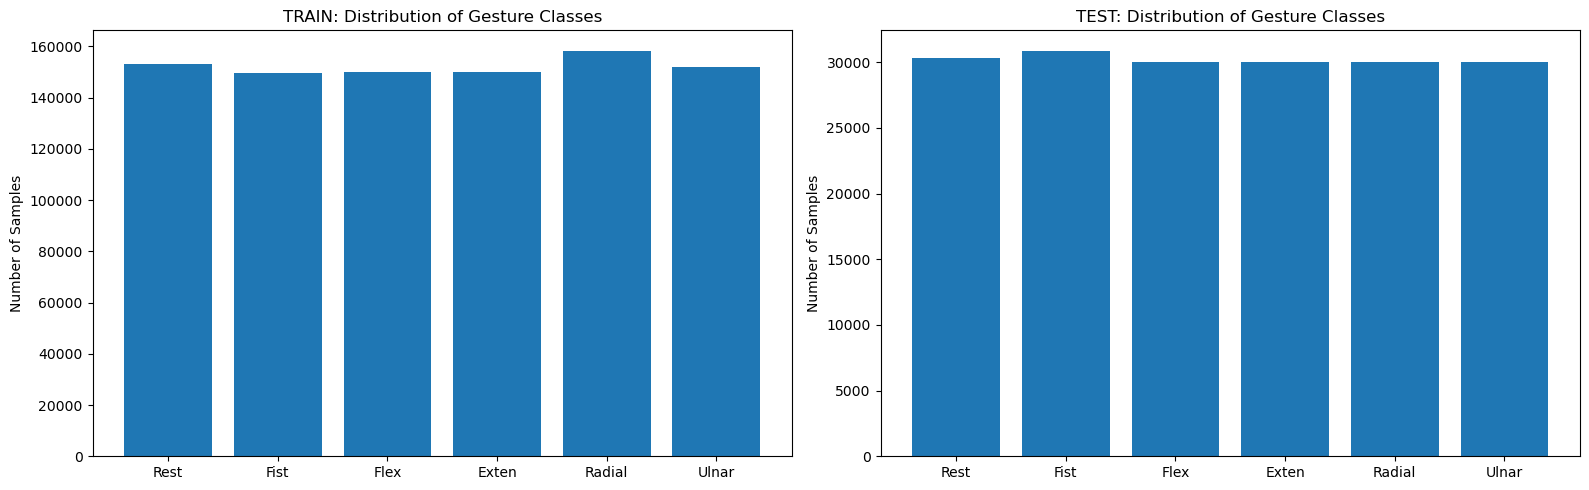

In [73]:


def viewData(X_train, X_test, y_train, y_test):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    ax1.hist(y_train, bins=range(NUM_CLASSES+1), align='left', rwidth=0.8)
    ax1.set_xticks(range(NUM_CLASSES))
    ax1.set_xticklabels(GESTURES)
    ax1.set_title("TRAIN: Distribution of Gesture Classes")
    ax1.set_ylabel("Number of Samples")

    ax2.hist(y_test, bins=range(NUM_CLASSES+1), align='left', rwidth=0.8)
    ax2.set_xticks(range(NUM_CLASSES))
    ax2.set_xticklabels(GESTURES)
    ax2.set_title("TEST: Distribution of Gesture Classes")
    ax2.set_ylabel("Number of Samples")

    print(f"TRAINING data shape: {X_train.shape}")
    print(f"TESTING data shape: {X_test.shape}")
    plt.tight_layout()
    plt.show()

viewData(X_train_raw, X_test_raw, y_train_raw, y_test_raw)

### 1c. Time-Window Data

In [74]:
# only accepts PERFECT WINDOWS (i.e doesn't fill with dumby 0's)
def create_windows_pure(X, y, window_size, stride):
    X_win = []
    y_win = []
    loss_data = 0
    for i in range(0, len(y) - window_size + 1, stride):
        X_temp_window = X[i : i + window_size] 
        y_temp_window = y[i : i + window_size] 
        perfect, jump_val = isPure_window(y_temp_window)
        
        if not perfect:
            loss_data += 1
            # INCOMPLETE, not needed with data this large.
            # might be helpful with FT on user data
            # jump by index instead of stride to not waste data 
            continue
        
        # We transpose so shape becomes (8, WINDOW_SIZE) instead of (WINDOW_SIZE, 8)
        X_win.append(X_temp_window.T) 
        y_win.append(y[i])
    print(f"Data Loss to impure windows: {loss_data}")
    return np.array(X_win), np.array(y_win)


def isPure_window(y_win):
    prev = y_win[0]
    for i in range(len(y_win)):
        if y_win[i] != prev:
            return False, i
        else:
            prev = y_win[i]
    
    return True, 0  


def create_windows_majority(X, y, window_size, stride):
    X_win = []
    y_win = []
    lost_data = 0
    for i in range(0, len(y) - window_size + 1, stride):
        X_temp_window = X[i : i + window_size] 
        y_temp_window = y[i : i + window_size] 
        label = majorityClass_window(y_temp_window)
        
        if label is None:  
            lost_data += 1
            continue
        
        X_win.append(X_temp_window.T) 
        y_win.append(label)

    print(f"Data Loss to impure windows: {lost_data}")
    return np.array(X_win), np.array(y_win)


def majorityClass_window(y_win):
    counts = np.zeros(7)
    size = len(y_win)

    for val in y_win:
        counts[int(val)] += 1

    majLabel_idx = counts.argmax()

    if counts[majLabel_idx] > size / 2:
        return majLabel_idx  
    
    return None  

def create_windows_last(data, window_size, stride):
    pass

if WINDOW_TYPE=='pure':
    print("Creating PURE Windowed TRAINING data")
    X_train, y_train = create_windows_pure(X_train_raw, y_train_raw, window_size=WINDOW_SIZE, stride=STRIDE)
    print("Creating PURE Windowed TESTING data")
    X_test, y_test = create_windows_pure(X_test_raw, y_test_raw, window_size=WINDOW_SIZE, stride=STRIDE)
elif WINDOW_TYPE=='majority':
    print("Creating MAJORITY Windowed TRAINING data")
    X_train, y_train = create_windows_majority(X_train_raw, y_train_raw, window_size=WINDOW_SIZE, stride=STRIDE)
    print("Creating MAJORITY Windowed TESTING data")
    X_test, y_test = create_windows_majority(X_test_raw, y_test_raw, window_size=WINDOW_SIZE, stride=STRIDE)
else: 
    print("NOT a valid window type.")
    print("Please set WINDOW_TYPE to \'pure\' OR \'majority\'")

Creating PURE Windowed TRAINING data
Data Loss to impure windows: 118
Creating PURE Windowed TESTING data
Data Loss to impure windows: 22


### Sanity Check: Data properly Windowed

TRAINING data shape: (7015, 8, 256)
TESTING data shape: (1392, 8, 256)


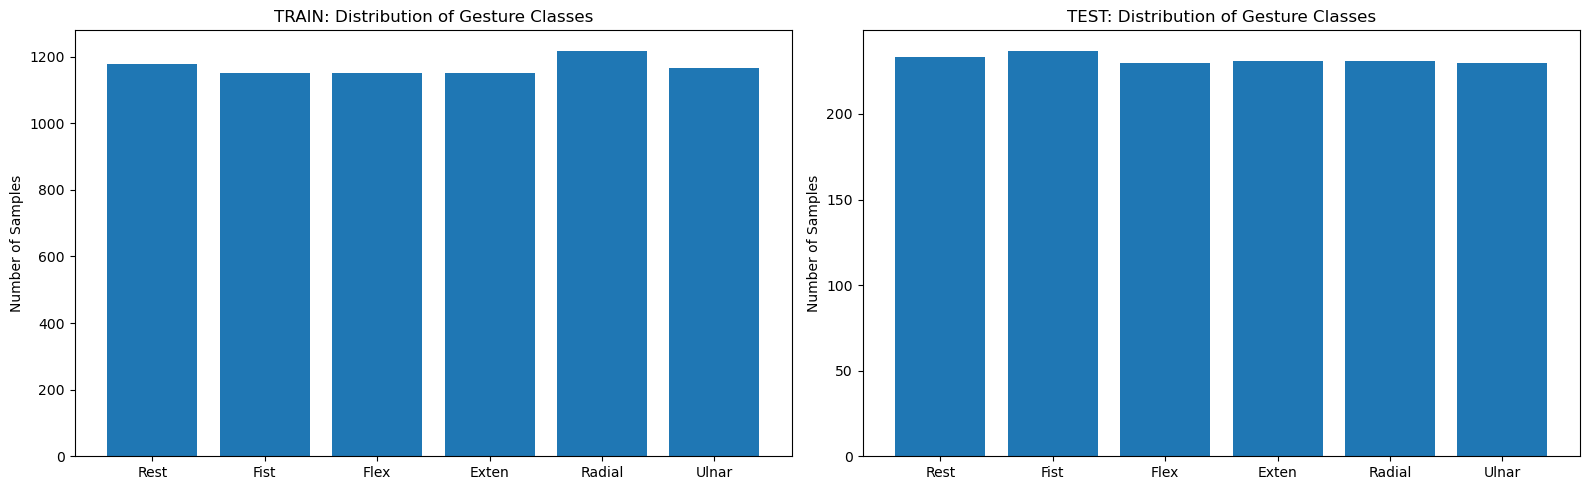

In [75]:
viewData(X_train, X_test, y_train, y_test)

## 2. Setup Model Training

### 2a. Set up layers for CNN

In [76]:
class SimpleEMGFANet(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super(SimpleEMGFANet, self).__init__()
        
        # Layer 1: Look for local patterns across the 8 channels
        # Input shape: (Batch, 8, Window_Size)
        # 8 due to the 8 channels of actual input data
        # 32 being a simple power of 2, big enough to capture complexity, small enough for laptop lol
        # 3 length of "filter" itself, smaller given high noise data like EMG
        # 1 gives data length same after convolution
        self.conv1 = nn.Conv1d(in_channels=8, out_channels=32, kernel_size=3, padding=1)
        
        # Layer 2: Deeper features
        # same as above, but with a second layer lol
        # higher scale given # of outputs from prev
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        
        # Layer 3: Channel Attention (The 'Adaptable' part of FANet)
        # Effictivly maps sensor vars to action
        # Ex: association between high activity in sensor 1 & 2 and fist gesture
        self.attention = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Conv1d(64, 16, 1),
            nn.ReLU(),
            nn.Conv1d(16, 64, 1),
            nn.Sigmoid()
        )
        
        # Final Classifier
        self.fc = nn.Linear(64, num_classes)
    
    # function to allow forward pass through to begin training
    def forward(self, x):
        # 1. Feature Extraction
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        
        # 2. Apply Attention
        weights = self.attention(x)
        x = x * weights
        
        # 3. Global Average Pooling (reduces time dimension to 1)
        x = torch.mean(x, dim=2) 
        
        # 4. Classify
        x = self.fc(x)
        return x


### 2b. Initialize Model + Loss Function + Optimizer

In [77]:
model = SimpleEMGFANet(num_classes=NUM_CLASSES)
device = torch.device("cpu")
model.to(device)
criterion = nn.CrossEntropyLoss()

# Optimizer to update actual weights of NN & MIN loss
# Adam specifically well adept to not geting stuck in local mins
# tracks velocity of weighting updates, allows to curve change if fickle
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

### 2c. Train Loader Setup

In [78]:
# Wrap processed NumPy arrays into TensorDataset
# X_train: (Samples, 8, WINDOW_SIZE)
# y_train: (Samples,)
train_data_tensor = TensorDataset(
    torch.from_numpy(X_train).float(), 
    torch.from_numpy(y_train).long()
)
train_loader = DataLoader(
    train_data_tensor, 
    batch_size=32, 
    shuffle=True
)

test_data_tensor = TensorDataset(
    torch.from_numpy(X_test).float(), 
    torch.from_numpy(y_test).long()
)
test_loader = DataLoader(
    test_data_tensor, 
    batch_size=32, 
    shuffle=True
)

# Check the first batch
data_iter = iter(train_loader)
images, labels = next(data_iter)
print(images.shape) # Should be [32, 8, WINDOW_SIZE]

torch.Size([32, 8, 256])


#### TensorBoard Reporting Setup

In [79]:
tensorboard_log_dir = os.path.join(f"logs/{DATA_SOURCE}", datetime.datetime.now().strftime("%Y%m%d-%H%M"))
# writer = SummaryWriter(tensorboard_log_dir)

## 3. Train

### 3a. Training Loop

In [80]:
def trainCNN_EMG(epochs: int, lambda_reg=LAMBDA, regularize_l2=L2):
    train_losses = []
    test_losses = []
    # Evaluate Random peformance
    avg_train_loss = eval_model(train_loader)
    avg_test_loss = eval_model(test_loader)
    print(f"Initial Train Peformance: {avg_train_loss:.4f}") 
    print(f"Initial Test  Peformance: {avg_test_loss:.4f}") 
    # writer.add_scalars(
    #     f"Loss/Test",
    #     {f"{CONFIG_NAME}": avg_test_loss},
    #     0
    # ) 
    # writer.add_scalars(
    #     f"Loss_{CONFIG_NAME}",
    #     {"TRAIN": avg_train_loss, "TEST": avg_test_loss},
    #     0
    # )   
    train_losses.append(avg_train_loss)
    test_losses.append(avg_test_loss)
    # Begin Real Training
    for epoch in range(epochs):
        # --- TRAIN ---
        model.train() 
        total_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            # 1. Zero the gradients (clear prev memory)
            optimizer.zero_grad()
            # 2. Forward pass: Compute predicted outputs
            outputs = model(inputs)
            # 3. Calculate loss (Cross Entropy Loss)
            raw_loss = criterion(outputs, labels)
            # 3a. Apply L2 regularization, hopefully to counter overfitting
            loss = raw_loss
            if regularize_l2:
                # taken from https://www.geeksforgeeks.org/machine-learning/l1l2-regularization-in-pytorch/
                l2_norm = sum(p.pow(2).sum() for p in model.parameters())
                loss += lambda_reg * l2_norm
            # 4. Backward pass: Compute gradient of the loss with respect to model parameters 
            loss.backward()
            # 5. Perform single optimization step (Adam)
            optimizer.step()
            
            total_loss += raw_loss.item()
        avg_train_loss = total_loss / len(train_loader)
        avg_test_loss = eval_model(test_loader)

        # --- LOG ---
        print(f"Epoch [{epoch+1}/{epochs}], TRAIN Loss: {avg_train_loss:.4f}")
        print(f"Epoch [{epoch+1}/{epochs}], TEST  Loss: {avg_test_loss:.4f}")
        # # Write Train/Test
        # writer.add_scalars(
        #     f"Loss_{CONFIG_NAME}",
        #     {"TRAIN": avg_train_loss, "TEST": avg_test_loss},
        #     epoch+1
        # )
        # # Write to MASTER 
        # writer.add_scalars(
        #     f"Loss/Test",
        #     {f"{CONFIG_NAME}": avg_test_loss},
        #     epoch+1
        # )
        train_losses.append(avg_train_loss)
        test_losses.append(avg_test_loss)

    print("Finished Training")
    return train_losses, test_losses


def eval_model(data_loader):
    model.eval() 
    total_loss = 0.0
    with torch.no_grad(): 
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
    avg_loss = total_loss / len(data_loader)

    return avg_loss


train_loss, test_loss = trainCNN_EMG(epochs=EPOCHS)


Initial Train Peformance: 1.7949
Initial Test  Peformance: 1.7986
Epoch [1/10], TRAIN Loss: 1.5992
Epoch [1/10], TEST  Loss: 1.1324
Epoch [2/10], TRAIN Loss: 1.1900
Epoch [2/10], TEST  Loss: 0.8841
Epoch [3/10], TRAIN Loss: 1.0830
Epoch [3/10], TEST  Loss: 0.7852
Epoch [4/10], TRAIN Loss: 1.0386
Epoch [4/10], TEST  Loss: 0.9001
Epoch [5/10], TRAIN Loss: 1.0066
Epoch [5/10], TEST  Loss: 0.7842
Epoch [6/10], TRAIN Loss: 0.9894
Epoch [6/10], TEST  Loss: 0.7342
Epoch [7/10], TRAIN Loss: 0.9753
Epoch [7/10], TEST  Loss: 0.7702
Epoch [8/10], TRAIN Loss: 0.9534
Epoch [8/10], TEST  Loss: 0.7063
Epoch [9/10], TRAIN Loss: 0.9444
Epoch [9/10], TEST  Loss: 0.8063
Epoch [10/10], TRAIN Loss: 0.9322
Epoch [10/10], TEST  Loss: 0.8374
Finished Training


### 3b. Save Model

In [81]:
MODELPATH = os.path.join("models",DATA_SOURCE,f"CNN-FANET_{CONFIG_NAME}.pth")
torch.save(model.state_dict(), MODELPATH)
print(f"saved {MODELPATH}")

saved models\bme\CNN-FANET_PW256_S128_LR0.001_E10_L20.001.pth


## 4. Evaluate Model

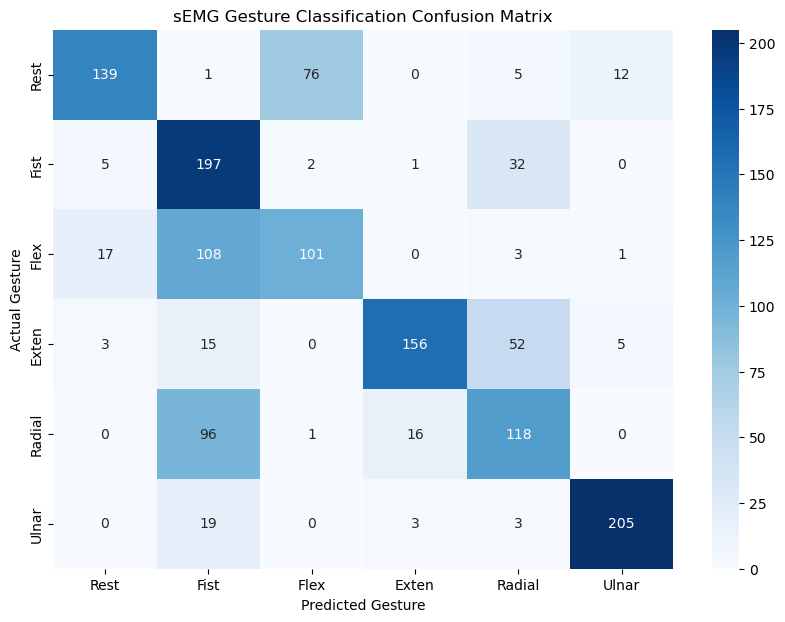

MCC: 0.5988
              precision    recall  f1-score   support

        Rest       0.85      0.60      0.70       233
        Fist       0.45      0.83      0.59       237
        Flex       0.56      0.44      0.49       230
       Exten       0.89      0.68      0.77       231
      Radial       0.55      0.51      0.53       231
       Ulnar       0.92      0.89      0.91       230

    accuracy                           0.66      1392
   macro avg       0.70      0.66      0.66      1392
weighted avg       0.70      0.66      0.66      1392



In [82]:
def evaluate_model(model, test_loader):
    model.eval()  # Set model to evaluation mode
    all_preds = []
    all_labels = []
    with torch.no_grad(): # No need to track gradients during testing
        for inputs, labels in test_loader:
            # Forward pass
            outputs = model(inputs)
            
            # Get the index of the highest value (the predicted class)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_labels), np.array(all_preds)

# Run Evaluation
y_true, y_pred = evaluate_model(model, test_loader)
test_mcc = matthews_corrcoef(y_true, y_pred)  # ranges -1 to 1, 1 being perfect

# Create Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Plot using Seaborn for a cuter look
fig = plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='.0f', cmap='Blues', 
            xticklabels=GESTURES, 
            yticklabels=GESTURES)
plt.xlabel('Predicted Gesture')
plt.ylabel('Actual Gesture')
plt.title('sEMG Gesture Classification Confusion Matrix')
plt.show()
print(f"MCC: {test_mcc:.4f}")
print(classification_report(y_true, y_pred, target_names=GESTURES))

# --- NEW TENSORBOARD LOGGING STEPS ---
# 5. Log Confusion Matrix Plot
# writer.add_figure(f'Confusion_Matrix/{CONFIG_NAME}', fig)

# # 6. Log MCC score
# writer.add_scalar(f'MCC/{CONFIG_NAME}', test_mcc)
